# Notebook 03: dataset de regresión

Este notebook construye `df_regresion` para predecir `cantidad` por venta. Usa joins entre ventas, clientes, productos y tiendas, e incorpora variables de ingeniería disponibles antes del evento para evitar data leakage.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

base_dir = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
data_dir = base_dir / 'datos'

print(f'Directorio base: {base_dir}')
print(f'Directorio de datos: {data_dir}')

Directorio base: c:\repos\Analitica_Datos_01\proyecto-andinaretail
Directorio de datos: c:\repos\Analitica_Datos_01\proyecto-andinaretail\datos


In [10]:
# Carga de tablas

df_ventas = pd.read_csv(data_dir / 'ventas.csv')
df_clientes = pd.read_csv(data_dir / 'clientes.csv')
df_productos = pd.read_csv(data_dir / 'productos.csv')
df_tiendas = pd.read_csv(data_dir / 'tiendas.csv')
df_inventario = pd.read_csv(data_dir / 'inventario.csv')

for nombre, df in {
    'ventas': df_ventas,
    'clientes': df_clientes,
    'productos': df_productos,
    'tiendas': df_tiendas,
    'inventario': df_inventario,
}.items():
    print(f'{nombre}: {df.shape}')
    display(df.head(2))

ventas: (250137, 11)


,id_venta,fecha,id_cliente,id_tienda,id_producto,cantidad,precio_unitario,descuento_pct,monto_total,canal,metodo_pago
0,1,2023-01-01,5051,4,426,1.0,41.26,16.50,34.45,Tienda Física,Tarjeta
1,2,2023-01-01,7791,2,249,1.0,28.05,4.09,26.90,Tienda Física,Efectivo


clientes: (15000, 9)


,id_cliente,nombre,edad,genero,ciudad,distrito,fecha_registro,canal_preferido,segmento
0,1,Jaqueline Barela Nazario,41.0,F,Arequipa,Paucarpata,2022-03-20,Tienda Física,Ocasional
1,2,Flavio Renato Corrales Zamudio,42.0,M,Trujillo,Mansiche,2020-05-16,Web,Nuevo


productos: (800, 8)


,id_producto,nombre,categoria,subcategoria,marca,precio_lista,costo_unitario,fecha_alta
0,1,Rexona Shampoo Casa,Cuidado Personal,Shampoo,Rexona,41.38,32.90,2020-03-14
1,2,Sapolio Limpiadores Mil,Limpieza,Limpiadores,Sapolio,32.46,21.15,2020-03-16


tiendas: (12, 7)


,id_tienda,nombre,ciudad,region,tipo,area_m2,fecha_apertura
0,1,AndinaRetail Lima Hipermercado 1,Lima,Lima,Hipermercado,6096.73,2017-03-05
1,2,AndinaRetail Lima Hipermercado 2,Lima,Lima,Hipermercado,9805.94,2021-07-09


inventario: (9600, 7)


,id_producto,id_tienda,stock,stock_minimo,stock_maximo,costo_almacenamiento,ultima_actualizacion
0,1,1,19.0,3.0,28.0,3.77,2025-12-23
1,1,2,25.0,5.0,37.0,3.88,2025-12-24


## Base del dataset

Se toma `ventas` como tabla base y se agregan atributos de clientes, productos y tiendas con `left join` para conservar todas las transacciones. Después se construyen variables históricas con `shift` y `cumsum` para garantizar que no se use información futura.

### Nota sobre inventario

La tabla `inventario` se carga para exploración, pero no se incorpora al dataset de regresión porque su snapshot está fechado al cierre de 2025 y no está alineado temporalmente con cada venta. Incluirla introduciría leakage y sesgos de disponibilidad futura.

In [11]:
# Construcción de la base de modelado con joins y features temporales

def buscar_directorio_datos(inicio: Path) -> Path:
    candidatos = [inicio, inicio.parent, inicio.parent.parent]
    for candidato in candidatos:
        if (candidato / 'datos').exists():
            return candidato
        if (candidato / 'proyecto-andinaretail' / 'datos').exists():
            return candidato / 'proyecto-andinaretail'
    raise FileNotFoundError('No se encontró el directorio de datos.')

base_dir = buscar_directorio_datos(Path.cwd())
data_dir = base_dir / 'datos'

ventas = df_ventas.copy()
clientes = df_clientes[[
    'id_cliente', 'edad', 'genero', 'ciudad', 'distrito', 'fecha_registro', 'canal_preferido', 'segmento'
]].copy()
productos = df_productos[[
    'id_producto', 'categoria', 'subcategoria', 'marca', 'precio_lista', 'costo_unitario', 'fecha_alta'
]].copy()
tiendas = df_tiendas[[
    'id_tienda', 'ciudad', 'region', 'tipo', 'area_m2', 'fecha_apertura'
]].copy()

clientes = clientes.rename(columns={
    'ciudad': 'ciudad_cliente',
    'distrito': 'distrito_cliente',
    'fecha_registro': 'fecha_registro_cliente'
})
productos = productos.rename(columns={'fecha_alta': 'fecha_alta_producto'})
tiendas = tiendas.rename(columns={
    'ciudad': 'ciudad_tienda',
    'region': 'region_tienda',
    'tipo': 'tipo_tienda',
    'fecha_apertura': 'fecha_apertura_tienda'
})

ventas['fecha'] = pd.to_datetime(ventas['fecha'])
clientes['fecha_registro_cliente'] = pd.to_datetime(clientes['fecha_registro_cliente'])
productos['fecha_alta_producto'] = pd.to_datetime(productos['fecha_alta_producto'])
tiendas['fecha_apertura_tienda'] = pd.to_datetime(tiendas['fecha_apertura_tienda'])

# El orden temporal es clave para construir variables históricas sin usar información futura.
ventas = ventas.sort_values(['id_cliente', 'fecha', 'id_venta']).reset_index(drop=True)

df_base = (
    ventas
    .merge(clientes, on='id_cliente', how='left')
    .merge(productos, on='id_producto', how='left')
    .merge(tiendas, on='id_tienda', how='left')
)

# Variables temporales conocidas al momento de la venta
df_base['anio_venta'] = df_base['fecha'].dt.year
df_base['mes_venta'] = df_base['fecha'].dt.month
df_base['trimestre_venta'] = df_base['fecha'].dt.quarter
df_base['dia_semana_venta'] = df_base['fecha'].dt.dayofweek
df_base['es_fin_de_semana'] = (df_base['dia_semana_venta'] >= 5).astype(int)
df_base['es_temporada_alta'] = df_base['mes_venta'].isin([7, 12]).astype(int)
df_base['es_trujillo_post_q2_2025'] = ((df_base['ciudad_tienda'] == 'Trujillo') & (df_base['fecha'] >= pd.Timestamp('2025-04-01'))).astype(int)

# Antiguedad calculada a partir de fechas ya observables en cada venta
df_base['antiguedad_cliente_dias'] = (df_base['fecha'] - df_base['fecha_registro_cliente']).dt.days.clip(lower=0)
df_base['antiguedad_producto_dias'] = (df_base['fecha'] - df_base['fecha_alta_producto']).dt.days.clip(lower=0)
df_base['antiguedad_tienda_dias'] = (df_base['fecha'] - df_base['fecha_apertura_tienda']).dt.days.clip(lower=0)

df_base['canal_digital'] = df_base['canal'].isin(['Web', 'App']).astype(int)
df_base['monto_historial'] = df_base['monto_total'].fillna(0)

grupo_cliente = df_base.groupby('id_cliente', sort=False)
df_base['frecuencia_previas'] = grupo_cliente.cumcount()
df_base['gasto_acumulado_previo'] = grupo_cliente['monto_historial'].transform(lambda s: s.shift().cumsum()).fillna(0)
df_base['fecha_compra_anterior'] = grupo_cliente['fecha'].shift()
df_base['recencia_prev_dias'] = (df_base['fecha'] - df_base['fecha_compra_anterior']).dt.days.fillna(9999)
df_base['compras_digitales_previas'] = grupo_cliente['canal_digital'].transform(lambda s: s.shift().cumsum()).fillna(0)
df_base['ticket_promedio_previo'] = np.where(
    df_base['frecuencia_previas'] > 0,
    df_base['gasto_acumulado_previo'] / df_base['frecuencia_previas'],
    0
)
df_base['proporcion_digital_previa'] = np.where(
    df_base['frecuencia_previas'] > 0,
    df_base['compras_digitales_previas'] / df_base['frecuencia_previas'],
    0
)

print('Base unificada:')
print(df_base.shape)
display(df_base.head(3))

Base unificada:
(250137, 48)


,id_venta,fecha,id_cliente,id_tienda,id_producto,cantidad,precio_unitario,descuento_pct,monto_total,canal,metodo_pago,edad,genero,ciudad_cliente,distrito_cliente,fecha_registro_cliente,canal_preferido,segmento,categoria,subcategoria,marca,precio_lista,costo_unitario,fecha_alta_producto,ciudad_tienda,region_tienda,tipo_tienda,area_m2,fecha_apertura_tienda,anio_venta,mes_venta,trimestre_venta,dia_semana_venta,es_fin_de_semana,es_temporada_alta,es_trujillo_post_q2_2025,antiguedad_cliente_dias,antiguedad_producto_dias,antiguedad_tienda_dias,canal_digital,monto_historial,frecuencia_previas,gasto_acumulado_previo,fecha_compra_anterior,recencia_prev_dias,compras_digitales_previas,ticket_promedio_previo,proporcion_digital_previa
0,5155,2023-01-26,1,12,129,1.0,25.79,10.16,23.17,App,Yape,41.0,F,Arequipa,Paucarpata,2022-03-20,Tienda Física,Ocasional,Bebidas,Cervezas,Cusqueña,24.57,18.03,2020-08-06,Piura,Piura,Virtual,48.34,2015-10-20,2023,1,1,3,0,0,0,312.0,903,2655,1,23.17,0,0.00,NaT,9999.0,0.0,0.00,0.0
1,8399,2023-02-11,1,10,180,1.0,23.52,18.86,19.09,Tienda Física,Plin,41.0,F,Arequipa,Paucarpata,2022-03-20,Tienda Física,Ocasional,Bebidas,Licores,Red Bull,23.22,15.58,2022-06-26,Cusco,Cusco,Supermercado,1036.13,2020-02-06,2023,2,1,5,1,0,0,328.0,230,1101,0,19.09,1,23.17,2023-01-26,16.0,1.0,23.17,1.0
2,26982,2023-05-12,1,4,269,3.0,28.91,21.57,68.03,Tienda Física,Efectivo,41.0,F,Arequipa,Paucarpata,2022-03-20,Tienda Física,Ocasional,Limpieza,Trapeadores,Glade,28.67,17.54,2022-08-17,Lima,Lima,Supermercado,2823.43,2022-07-28,2023,5,2,4,0,0,0,418.0,268,288,0,68.03,2,42.26,2023-02-11,90.0,1.0,21.13,0.5


In [12]:
# Selección final, imputación y prevención de leakage

columnas_finales = [
    'cantidad',
    'anio_venta', 'mes_venta', 'trimestre_venta', 'dia_semana_venta', 'es_fin_de_semana', 'es_temporada_alta', 'es_trujillo_post_q2_2025',
    'categoria', 'subcategoria', 'marca', 'precio_lista', 'costo_unitario', 'antiguedad_producto_dias',
    'ciudad_tienda', 'region_tienda', 'tipo_tienda', 'area_m2', 'antiguedad_tienda_dias',
    'edad', 'genero', 'ciudad_cliente', 'distrito_cliente', 'canal_preferido', 'segmento', 'antiguedad_cliente_dias',
    'frecuencia_previas', 'gasto_acumulado_previo', 'ticket_promedio_previo', 'recencia_prev_dias', 'proporcion_digital_previa'
]

# No incluir variables que exponen el resultado de la venta o identificadores directos.
columnas_prohibidas = ['id_venta', 'fecha', 'id_cliente', 'id_tienda', 'id_producto', 'precio_unitario', 'descuento_pct', 'monto_total', 'fecha_registro_cliente', 'fecha_alta_producto', 'fecha_apertura_tienda']
presentes_prohibidas = [col for col in columnas_prohibidas if col in df_base.columns]
print('Columnas prohibidas presentes en la base (no se usarán como features):')
print(presentes_prohibidas)

df_regresion = df_base[columnas_finales].copy()
df_regresion = df_regresion.dropna(subset=['cantidad']).reset_index(drop=True)

columnas_numericas = df_regresion.select_dtypes(include=['number']).columns.tolist()
columnas_categoricas = df_regresion.select_dtypes(include=['object']).columns.tolist()

for columna in columnas_numericas:
    if df_regresion[columna].isna().any():
        df_regresion[columna] = df_regresion[columna].fillna(df_regresion[columna].median())

for columna in columnas_categoricas:
    if df_regresion[columna].isna().any():
        moda = df_regresion[columna].mode(dropna=True)
        relleno = moda.iloc[0] if not moda.empty else 'Desconocido'
        df_regresion[columna] = df_regresion[columna].fillna(relleno)

assert 'monto_total' not in df_regresion.columns
assert 'descuento_pct' not in df_regresion.columns
assert 'precio_unitario' not in df_regresion.columns
assert 'id_venta' not in df_regresion.columns

print('df_regresion listo:')
print(df_regresion.shape)
print(df_regresion.columns.tolist())
display(df_regresion.head())

ruta_salida = data_dir / 'df_regresion.csv'
df_regresion.to_csv(ruta_salida, index=False, encoding='utf-8')
print(f'Dataset exportado en: {ruta_salida}')

Columnas prohibidas presentes en la base (no se usarán como features):
['id_venta', 'fecha', 'id_cliente', 'id_tienda', 'id_producto', 'precio_unitario', 'descuento_pct', 'monto_total', 'fecha_registro_cliente', 'fecha_alta_producto', 'fecha_apertura_tienda']
df_regresion listo:
(249472, 31)
['cantidad', 'anio_venta', 'mes_venta', 'trimestre_venta', 'dia_semana_venta', 'es_fin_de_semana', 'es_temporada_alta', 'es_trujillo_post_q2_2025', 'categoria', 'subcategoria', 'marca', 'precio_lista', 'costo_unitario', 'antiguedad_producto_dias', 'ciudad_tienda', 'region_tienda', 'tipo_tienda', 'area_m2', 'antiguedad_tienda_dias', 'edad', 'genero', 'ciudad_cliente', 'distrito_cliente', 'canal_preferido', 'segmento', 'antiguedad_cliente_dias', 'frecuencia_previas', 'gasto_acumulado_previo', 'ticket_promedio_previo', 'recencia_prev_dias', 'proporcion_digital_previa']


,cantidad,anio_venta,mes_venta,trimestre_venta,dia_semana_venta,es_fin_de_semana,es_temporada_alta,es_trujillo_post_q2_2025,categoria,subcategoria,marca,precio_lista,costo_unitario,antiguedad_producto_dias,ciudad_tienda,region_tienda,tipo_tienda,area_m2,antiguedad_tienda_dias,edad,genero,ciudad_cliente,distrito_cliente,canal_preferido,segmento,antiguedad_cliente_dias,frecuencia_previas,gasto_acumulado_previo,ticket_promedio_previo,recencia_prev_dias,proporcion_digital_previa
0,1.0,2023,1,1,3,0,0,0,Bebidas,Cervezas,Cusqueña,24.57,18.03,903,Piura,Piura,Virtual,48.34,2655,41.0,F,Arequipa,Paucarpata,Tienda Física,Ocasional,312.0,0,0.00,0.000000,9999.0,0.000000
1,1.0,2023,2,1,5,1,0,0,Bebidas,Licores,Red Bull,23.22,15.58,230,Cusco,Cusco,Supermercado,1036.13,1101,41.0,F,Arequipa,Paucarpata,Tienda Física,Ocasional,328.0,1,23.17,23.170000,16.0,1.000000
2,3.0,2023,5,2,4,0,0,0,Limpieza,Trapeadores,Glade,28.67,17.54,268,Lima,Lima,Supermercado,2823.43,288,41.0,F,Arequipa,Paucarpata,Tienda Física,Ocasional,418.0,2,42.26,21.130000,90.0,0.500000
3,1.0,2023,6,2,2,0,0,0,Hogar,Textil Hogar,Fantasía,125.39,87.99,209,Lima,Lima,Hipermercado,9805.94,705,41.0,F,Arequipa,Paucarpata,Tienda Física,Ocasional,451.0,3,110.29,36.763333,33.0,0.333333
4,1.0,2023,6,2,2,0,0,0,Hogar,Decoración,Ripley Home,178.87,108.27,281,Piura,Piura,Virtual,48.34,2801,41.0,F,Arequipa,Paucarpata,Tienda Física,Ocasional,458.0,4,216.94,54.235000,7.0,0.250000


Dataset exportado en: c:\repos\Analitica_Datos_01\proyecto-andinaretail\datos\df_regresion.csv


## Validación final

El dataset queda preparado para entrenar modelos en una siguiente etapa. En este punto no se ajusta ningún algoritmo; solo se construye `df_regresion` con ingeniería de variables y controles de leakage.

## Preparación para Machine Learning

En esta sección se separa la variable objetivo, se identifican variables numéricas y categóricas, y se arma un pipeline de preprocesamiento listo para entrenamiento. No se ajusta ningún modelo todavía.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separación de variables
X = df_regresion.drop(columns=['cantidad']).copy()
y = df_regresion['cantidad'].copy()

# Identificación de tipos de variables
columnas_numericas_ml = X.select_dtypes(include=['number']).columns.tolist()
columnas_categoricas_ml = X.select_dtypes(include=['object']).columns.tolist()

print('Variables numéricas:')
print(columnas_numericas_ml)
print('\nVariables categóricas:')
print(columnas_categoricas_ml)

# Partición entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Pipelines de preprocesamiento
preprocesamiento_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

preprocesamiento_categorico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numericas', preprocesamiento_numerico, columnas_numericas_ml),
        ('categoricas', preprocesamiento_categorico, columnas_categoricas_ml)
    ],
    remainder='drop'
)

pipeline_preprocesamiento = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')
print('\nPipeline de preprocesamiento creado correctamente.')

Variables numéricas:
['anio_venta', 'mes_venta', 'trimestre_venta', 'dia_semana_venta', 'es_fin_de_semana', 'es_temporada_alta', 'es_trujillo_post_q2_2025', 'precio_lista', 'costo_unitario', 'antiguedad_producto_dias', 'area_m2', 'antiguedad_tienda_dias', 'edad', 'antiguedad_cliente_dias', 'frecuencia_previas', 'gasto_acumulado_previo', 'ticket_promedio_previo', 'recencia_prev_dias', 'proporcion_digital_previa']

Variables categóricas:
['categoria', 'subcategoria', 'marca', 'ciudad_tienda', 'region_tienda', 'tipo_tienda', 'genero', 'ciudad_cliente', 'distrito_cliente', 'canal_preferido', 'segmento']
X_train: (199577, 30)
X_test: (49895, 30)
y_train: (199577,)
y_test: (49895,)

Pipeline de preprocesamiento creado correctamente.


### Estado final

`df_regresion` ya quedó preparado para pasar a modelado supervisado. En esta etapa solo se definieron los datos de entrada, la partición de entrenamiento y prueba, y el preprocesamiento; no se entrenó ningún algoritmo.

## Entrenamiento y comparación de modelos

A partir del preprocesamiento ya definido, se entrenan dos modelos de regresión: `LinearRegression` y `RandomForestRegressor`. La comparación usa MAE, RMSE y R² sobre el conjunto de prueba.

In [14]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Aplicar el pipeline de preprocesamiento ya creado
X_train_preparado = pipeline_preprocesamiento.fit_transform(X_train)
X_test_preparado = pipeline_preprocesamiento.transform(X_test)

# Convertir a denso solo si el resultado viene en formato disperso
if hasattr(X_train_preparado, 'toarray'):
    X_train_preparado = X_train_preparado.toarray()
    X_test_preparado = X_test_preparado.toarray()

# ============================
# Entrenamiento de modelos
# ============================

# Linear Regression
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_preparado, y_train)
pred_lr = modelo_lr.predict(X_test_preparado)

# Random Forest
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train_preparado, y_train)
pred_rf = modelo_rf.predict(X_test_preparado)

# XGBoost
modelo_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
modelo_xgb.fit(X_train_preparado, y_train)
pred_xgb = modelo_xgb.predict(X_test_preparado)

# ============================
# Evaluación comparativa
# ============================

resultados_modelos = pd.DataFrame([
    {
        'modelo': 'LinearRegression',
        'MAE': mean_absolute_error(y_test, pred_lr),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_lr)),
        'R2': r2_score(y_test, pred_lr)
    },
    {
        'modelo': 'RandomForestRegressor',
        'MAE': mean_absolute_error(y_test, pred_rf),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf)),
        'R2': r2_score(y_test, pred_rf)
    },
    {
        'modelo': 'XGBRegressor',
        'MAE': mean_absolute_error(y_test, pred_xgb),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_xgb)),
        'R2': r2_score(y_test, pred_xgb)
    }
]).sort_values(by=['R2', 'RMSE'], ascending=[False, True]).reset_index(drop=True)

mejor_modelo = resultados_modelos.iloc[0]['modelo']

print('Tabla comparativa de modelos:')
display(resultados_modelos)
print(f'\nMejor modelo seleccionado: {mejor_modelo}')


Tabla comparativa de modelos:


,modelo,MAE,RMSE,R2
0,LinearRegression,1.049210,1.717669,0.078430
1,XGBRegressor,1.056728,1.737410,0.057126
2,RandomForestRegressor,1.081871,1.739630,0.054715



Mejor modelo seleccionado: LinearRegression


### Resultado

La comparación queda lista para continuar con el modelo ganador en una siguiente etapa, sin agregar más algoritmos ni alterar el pipeline de preparación.

## Optimización del mejor modelo

Se optimiza únicamente el modelo ganador actual (`LinearRegression`) con `RandomizedSearchCV`, usando 5 folds y `random_state=42`. Luego se compara el desempeño antes y después de la búsqueda.

In [16]:
from sklearn.model_selection import RandomizedSearchCV

# El mejor modelo previo fue LinearRegression, así que solo se optimiza ese estimador.
modelo_base = LinearRegression()

param_distributions_lr = {
    'fit_intercept': [True, False],
    'positive': [False, True],
    'copy_X': [True, False]
}

busqueda_lr = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions=param_distributions_lr,
    n_iter=6,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    refit=True
)

busqueda_lr.fit(X_train_preparado, y_train)

modelo_lr_optimizado = busqueda_lr.best_estimator_
pred_lr_optimizado = modelo_lr_optimizado.predict(X_test_preparado)

comparacion_lr = pd.DataFrame([
    {
        'etapa': 'Antes',
        'modelo': 'LinearRegression',
        'MAE': mean_absolute_error(y_test, pred_lr),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_lr)),
        'R2': r2_score(y_test, pred_lr)
    },
    {
        'etapa': 'Después',
        'modelo': 'LinearRegression optimizado',
        'MAE': mean_absolute_error(y_test, pred_lr_optimizado),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_lr_optimizado)),
        'R2': r2_score(y_test, pred_lr_optimizado)
    }
])

comparacion_lr['mejora_RMSE'] = comparacion_lr.loc[0, 'RMSE'] - comparacion_lr['RMSE']
comparacion_lr['mejora_R2'] = comparacion_lr['R2'] - comparacion_lr.loc[0, 'R2']

print('Mejores hiperparámetros encontrados:')
print(busqueda_lr.best_params_)
print(f"\nMejor RMSE en validación cruzada: {abs(busqueda_lr.best_score_):.6f}")
print('\nComparación antes y después:')
display(comparacion_lr)

Mejores hiperparámetros encontrados:
{'positive': True, 'fit_intercept': False, 'copy_X': False}

Mejor RMSE en validación cruzada: 1.625249

Comparación antes y después:


,etapa,modelo,MAE,RMSE,R2,mejora_RMSE,mejora_R2
0,Antes,LinearRegression,1.04921,1.717669,0.078430,0.000000,0.000000
1,Después,LinearRegression optimizado,1.04910,1.717598,0.078506,0.000071,0.000077


## Interpretación del mejor modelo

Se analiza el modelo de regresión optimizado para identificar las variables más influyentes. Para una regresión lineal, la importancia se obtiene a partir de los coeficientes. Si `shap` está disponible, también se genera una explicación SHAP.

Top 15 variables más influyentes por coeficientes:


,variable,coeficiente,importancia_absoluta
98,marca_Valle,2.867753,2.867753
69,marca_Costeño,2.842500,2.842500
71,marca_Doña Clara,2.821605,2.821605
87,marca_Primor,2.817954,2.817954
96,marca_Tondero,2.805783,2.805783
79,marca_Nicolini,2.798338,2.798338
89,marca_Red Bull,1.972056,1.972056
93,marca_San Mateo,1.941122,1.941122
67,marca_Coca-Cola,1.927810,1.927810
70,marca_Cusqueña,1.910907,1.910907


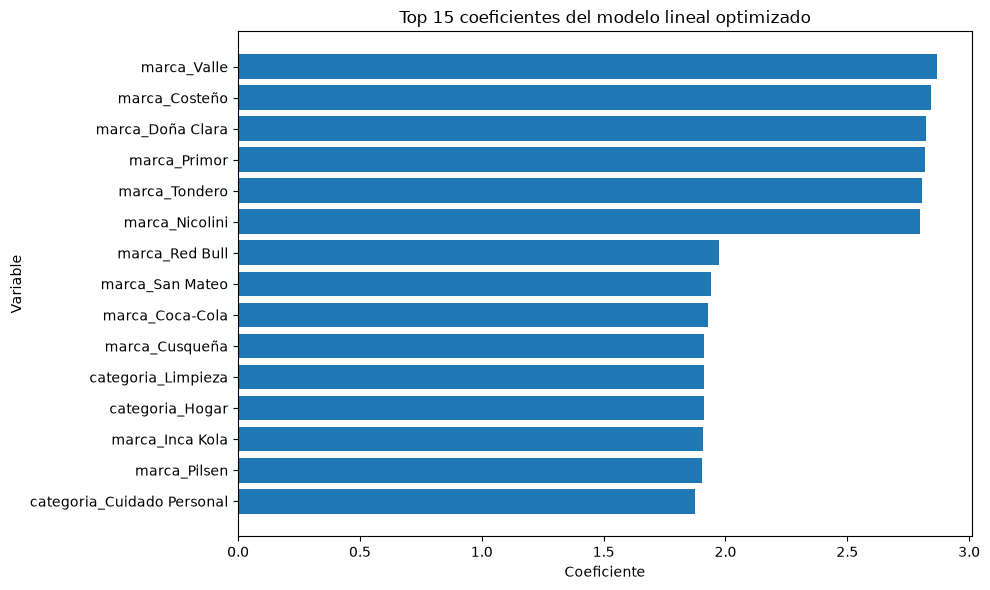

SHAP no está instalado en este entorno. Se mantiene la interpretación por coeficientes, que sí aplica para este modelo lineal.


In [17]:
import matplotlib.pyplot as plt

# Recuperar nombres de variables luego del preprocesamiento
nombres_features_numericas = columnas_numericas_ml
nombres_features_categoricas = list(
    pipeline_preprocesamiento.named_steps['preprocessor']
    .named_transformers_['categoricas']
    .named_steps['onehot']
    .get_feature_names_out(columnas_categoricas_ml)
)
nombres_features_transformadas = nombres_features_numericas + nombres_features_categoricas

# Importancia por coeficientes del modelo lineal optimizado
coeficientes = modelo_lr_optimizado.coef_
importancia_coeficientes = pd.DataFrame({
    'variable': nombres_features_transformadas,
    'coeficiente': coeficientes,
    'importancia_absoluta': np.abs(coeficientes)
}).sort_values('importancia_absoluta', ascending=False)

print('Top 15 variables más influyentes por coeficientes:')
display(importancia_coeficientes.head(15))

plt.figure(figsize=(10, 6))
orden_top = importancia_coeficientes.head(15).sort_values('importancia_absoluta', ascending=True)
plt.barh(orden_top['variable'], orden_top['coeficiente'])
plt.title('Top 15 coeficientes del modelo lineal optimizado')
plt.xlabel('Coeficiente')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# SHAP si está disponible
try:
    shap = __import__('shap')

    shap.initjs()
    shap_explainer = shap.LinearExplainer(modelo_lr_optimizado, X_train_preparado, feature_perturbation='interventional')
    shap_values = shap_explainer.shap_values(X_test_preparado)

    shap_importancia = pd.DataFrame({
        'variable': nombres_features_transformadas,
        'shap_abs_mean': np.abs(shap_values).mean(axis=0)
    }).sort_values('shap_abs_mean', ascending=False)

    print('Top 15 variables más influyentes por SHAP:')
    display(shap_importancia.head(15))

    plt.figure(figsize=(10, 6))
    orden_shap = shap_importancia.head(15).sort_values('shap_abs_mean', ascending=True)
    plt.barh(orden_shap['variable'], orden_shap['shap_abs_mean'])
    plt.title('Top 15 variables por importancia SHAP')
    plt.xlabel('SHAP medio absoluto')
    plt.ylabel('Variable')
    plt.tight_layout()
    plt.show()

    resumen_shap = shap.Explainer(modelo_lr_optimizado, X_train_preparado)
    shap.summary_plot(shap_values, X_test_preparado, feature_names=nombres_features_transformadas, show=True)
except ImportError:
    print('SHAP no está instalado en este entorno. Se mantiene la interpretación por coeficientes, que sí aplica para este modelo lineal.')

### Lectura de resultados

En un modelo lineal, un coeficiente positivo indica que al aumentar esa variable también tiende a aumentar `cantidad`, mientras que un coeficiente negativo sugiere el efecto contrario. Si SHAP está disponible, su ranking debe ser consistente con esta lectura global y ayuda a confirmar la influencia relativa de las variables.

## Dataset de clasificación

Se construye `df_clasificacion` para predecir `cliente_inactivo`, donde `1` indica que el cliente no tuvo compras en los últimos 90 días del período y `0` indica que sigue activo. Todas las agregaciones se calculan con historial anterior a la fecha de corte para evitar data leakage.

In [18]:
# Construcción mejorada del dataset de clasificación para churn

from pathlib import Path

import numpy as np
import pandas as pd

def buscar_directorio_datos(inicio: Path) -> Path:
    candidatos = [inicio, inicio.parent, inicio.parent.parent]
    for candidato in candidatos:
        if (candidato / 'datos').exists():
            return candidato
        if (candidato / 'proyecto-andinaretail' / 'datos').exists():
            return candidato / 'proyecto-andinaretail'
    raise FileNotFoundError('No se encontró el directorio de datos.')

base_dir_clasificacion = buscar_directorio_datos(Path.cwd())
data_dir_clasificacion = base_dir_clasificacion / 'datos'

df_ventas_clasificacion = pd.read_csv(data_dir_clasificacion / 'ventas.csv')
df_clientes_clasificacion = pd.read_csv(data_dir_clasificacion / 'clientes.csv')
df_productos_clasificacion = pd.read_csv(data_dir_clasificacion / 'productos.csv')

df_ventas_clasificacion['fecha'] = pd.to_datetime(df_ventas_clasificacion['fecha'])
df_clientes_clasificacion['fecha_registro'] = pd.to_datetime(df_clientes_clasificacion['fecha_registro'])

ventas_clasificacion = df_ventas_clasificacion.merge(
    df_productos_clasificacion[['id_producto', 'categoria']],
    on='id_producto',
    how='left'
)

fecha_maxima = ventas_clasificacion['fecha'].max()
fecha_corte = fecha_maxima - pd.Timedelta(days=90)
ventas_hist = ventas_clasificacion[ventas_clasificacion['fecha'] <= fecha_corte].copy()
ventas_total = ventas_clasificacion.copy()

# Agregados históricos por cliente usando solo información anterior al corte
agregados_hist = ventas_hist.groupby('id_cliente').agg(
    frecuencia_compra=('id_venta', 'count'),
    gasto_total_acumulado=('monto_total', 'sum'),
    cantidad_total_comprada=('cantidad', 'sum'),
    ticket_promedio=('monto_total', 'mean'),
    ultima_compra=('fecha', 'max'),
    meses_activos=('fecha', lambda s: s.dt.to_period('M').nunique()),
    numero_categorias_distintas=('categoria', 'nunique'),
    numero_productos_distintos=('id_producto', 'nunique'),
    descuento_promedio_utilizado=('descuento_pct', 'mean'),
    canal_mas_utilizado=('canal', lambda s: s.mode().iloc[0] if not s.mode().empty else 'Sin compra')
).reset_index()

agregados_hist['dias_desde_ultima_compra'] = (fecha_corte - agregados_hist['ultima_compra']).dt.days
agregados_hist['frecuencia_mensual_compra'] = np.where(
    agregados_hist['meses_activos'] > 0,
    agregados_hist['frecuencia_compra'] / agregados_hist['meses_activos'],
    0
)

# Target: 1 si no compra en los últimos 90 días del período, 0 si sigue activo
ultima_compra_total = ventas_total.groupby('id_cliente')['fecha'].max().reset_index().rename(columns={'fecha': 'ultima_compra_total'})

base_clientes = df_clientes_clasificacion[[
    'id_cliente', 'edad', 'genero', 'ciudad', 'distrito', 'segmento'
]].rename(columns={
    'ciudad': 'ciudad_cliente',
    'distrito': 'distrito_cliente'
})

df_clasificacion = (
    base_clientes
    .merge(agregados_hist, on='id_cliente', how='left')
    .merge(ultima_compra_total, on='id_cliente', how='left')
)

df_clasificacion['cliente_inactivo'] = np.where(
    df_clasificacion['ultima_compra_total'].isna() | (df_clasificacion['ultima_compra_total'] <= fecha_corte),
    1,
    0
)

# Completar clientes sin historial previo al corte
columnas_cero = [
    'frecuencia_compra', 'gasto_total_acumulado', 'cantidad_total_comprada', 'ticket_promedio',
    'dias_desde_ultima_compra', 'frecuencia_mensual_compra', 'numero_categorias_distintas',
    'numero_productos_distintos', 'descuento_promedio_utilizado'
]
for columna in columnas_cero:
    df_clasificacion[columna] = df_clasificacion[columna].fillna(0)

df_clasificacion['canal_mas_utilizado'] = df_clasificacion['canal_mas_utilizado'].fillna('Sin compra')

# Revisión y eliminación de variables poco útiles: se excluyen IDs y fechas crudas del dataset final
columnas_finales_clasificacion = [
    'cliente_inactivo',
    'frecuencia_compra',
    'gasto_total_acumulado',
    'cantidad_total_comprada',
    'ticket_promedio',
    'dias_desde_ultima_compra',
    'frecuencia_mensual_compra',
    'numero_categorias_distintas',
    'numero_productos_distintos',
    'canal_mas_utilizado',
    'descuento_promedio_utilizado',
    'segmento',
    'edad',
    'genero',
    'ciudad_cliente',
    'distrito_cliente'
]

df_clasificacion = df_clasificacion[columnas_finales_clasificacion].copy()

print('Fecha máxima de ventas:', fecha_maxima.date())
print('Fecha de corte para inactividad:', fecha_corte.date())
print('Distribución del target:')
display(df_clasificacion['cliente_inactivo'].value_counts().rename_axis('cliente_inactivo').reset_index(name='conteo'))
print('\ndf_clasificacion listo:')
print(df_clasificacion.shape)
display(df_clasificacion.head())

ruta_salida_clasificacion = data_dir_clasificacion / 'df_clasificacion.csv'
df_clasificacion.to_csv(ruta_salida_clasificacion, index=False, encoding='utf-8')
print(f'Dataset exportado en: {ruta_salida_clasificacion}')

Fecha máxima de ventas: 2025-12-31
Fecha de corte para inactividad: 2025-10-02
Distribución del target:


,cliente_inactivo,conteo
0,0,11952
1,1,3048



df_clasificacion listo:
(15000, 16)


,cliente_inactivo,frecuencia_compra,gasto_total_acumulado,cantidad_total_comprada,ticket_promedio,dias_desde_ultima_compra,frecuencia_mensual_compra,numero_categorias_distintas,numero_productos_distintos,canal_mas_utilizado,descuento_promedio_utilizado,segmento,edad,genero,ciudad_cliente,distrito_cliente
0,0,20,3272.22000,36.0,163.611000,10,1.428571,6,19,Tienda Física,12.850500,Ocasional,41.0,F,Arequipa,Paucarpata
1,1,17,6373.38000,38.0,374.904706,74,1.214286,6,16,Tienda Física,11.331176,Nuevo,42.0,M,Trujillo,Mansiche
2,0,11,4278.36000,22.0,388.941818,24,1.375000,5,11,Tienda Física,11.483636,Regular,35.0,F,Lima,Jesus María
3,0,16,3206.19072,34.0,200.386920,69,1.454545,5,16,Tienda Física,13.567333,Regular,24.0,M,Cusco,Santiago
4,0,20,5492.62000,47.0,274.631000,182,1.250000,6,19,Tienda Física,12.291500,Regular,18.0,F,Lima,San Miguel


Dataset exportado en: c:\repos\Analitica_Datos_01\proyecto-andinaretail\datos\df_clasificacion.csv


### Validación de leakage

El target se define con la última compra real del período completo, pero las variables predictoras se construyen solo con compras anteriores a la fecha de corte. De esta forma, `frecuencia_compra`, `gasto_total`, `ticket_promedio`, `ultima_compra`, `dias_inactividad`, `canal`, `segmento` y las variables demográficas quedan libres de fuga temporal para el entrenamiento posterior.

## Preparación para Machine Learning

En esta sección se separa la variable objetivo, se identifican variables numéricas y categóricas, y se arma un pipeline de preprocesamiento listo para entrenamiento. No se ajusta ningún modelo todavía.

In [19]:
from pathlib import Path

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def buscar_directorio_datos(inicio: Path) -> Path:
    candidatos = [inicio, inicio.parent, inicio.parent.parent]
    for candidato in candidatos:
        if (candidato / 'datos').exists():
            return candidato
        if (candidato / 'proyecto-andinaretail' / 'datos').exists():
            return candidato / 'proyecto-andinaretail'
    raise FileNotFoundError('No se encontró el directorio de datos.')

base_dir_clasificacion = buscar_directorio_datos(Path.cwd())
data_dir_clasificacion = base_dir_clasificacion / 'datos'

if 'df_clasificacion' not in globals():
    df_clasificacion = pd.read_csv(data_dir_clasificacion / 'df_clasificacion.csv')

# Separación de variables conservando solo las que aportan señal de comportamiento o perfil
columnas_modelo_clasificacion = [
    'frecuencia_compra',
    'gasto_total_acumulado',
    'cantidad_total_comprada',
    'ticket_promedio',
    'dias_desde_ultima_compra',
    'frecuencia_mensual_compra',
    'numero_categorias_distintas',
    'numero_productos_distintos',
    'canal_mas_utilizado',
    'descuento_promedio_utilizado',
    'segmento',
    'edad',
    'genero',
    'ciudad_cliente',
    'distrito_cliente'
]

X_clasificacion = df_clasificacion[columnas_modelo_clasificacion].copy()
y_clasificacion = df_clasificacion['cliente_inactivo'].copy()

# Identificación de tipos de variables
columnas_numericas_clasificacion = X_clasificacion.select_dtypes(include=['number']).columns.tolist()
columnas_categoricas_clasificacion = X_clasificacion.select_dtypes(include=['object']).columns.tolist()

print('Variables numéricas:')
print(columnas_numericas_clasificacion)
print('\nVariables categóricas:')
print(columnas_categoricas_clasificacion)

# Partición entrenamiento / prueba
X_train_clasificacion, X_test_clasificacion, y_train_clasificacion, y_test_clasificacion = train_test_split(
    X_clasificacion,
    y_clasificacion,
    test_size=0.2,
    random_state=42,
    stratify=y_clasificacion
)

# Pipelines de preprocesamiento
preprocesamiento_numerico_clasificacion = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

preprocesamiento_categorico_clasificacion = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_clasificacion = ColumnTransformer(
    transformers=[
        ('numericas', preprocesamiento_numerico_clasificacion, columnas_numericas_clasificacion),
        ('categoricas', preprocesamiento_categorico_clasificacion, columnas_categoricas_clasificacion)
    ],
    remainder='drop'
)

pipeline_preprocesamiento_clasificacion = Pipeline(steps=[
    ('preprocessor', preprocessor_clasificacion)
])

print(f'X_train_clasificacion: {X_train_clasificacion.shape}')
print(f'X_test_clasificacion: {X_test_clasificacion.shape}')
print(f'y_train_clasificacion: {y_train_clasificacion.shape}')
print(f'y_test_clasificacion: {y_test_clasificacion.shape}')
print('\nPipeline de preprocesamiento de clasificación creado correctamente.')

Variables numéricas:
['frecuencia_compra', 'gasto_total_acumulado', 'cantidad_total_comprada', 'ticket_promedio', 'dias_desde_ultima_compra', 'frecuencia_mensual_compra', 'numero_categorias_distintas', 'numero_productos_distintos', 'descuento_promedio_utilizado', 'edad']

Variables categóricas:
['canal_mas_utilizado', 'segmento', 'genero', 'ciudad_cliente', 'distrito_cliente']
X_train_clasificacion: (12000, 15)
X_test_clasificacion: (3000, 15)
y_train_clasificacion: (12000,)
y_test_clasificacion: (3000,)

Pipeline de preprocesamiento de clasificación creado correctamente.


### Estado final

`df_clasificacion` quedó listo para pasar a modelado supervisado. En esta etapa solo se definieron las variables predictoras, el target, la partición de entrenamiento y prueba, y el preprocesamiento; no se entrenó ningún algoritmo.

## Entrenamiento y comparación de modelos

A partir del preprocesamiento ya definido, se entrenan dos modelos de clasificación: `LogisticRegression` y `RandomForestClassifier`. La comparación usa Accuracy, Precision, Recall, F1-score, ROC AUC y la matriz de confusión sobre el conjunto de prueba.

In [20]:
# Análisis del balance de clases
conteo_clases = y_clasificacion.value_counts().sort_index()
proporcion_clases = y_clasificacion.value_counts(normalize=True).sort_index()

balance_clases = pd.DataFrame({
    'conteo': conteo_clases,
    'proporcion': proporcion_clases
})

print('Distribución de cliente_inactivo:')
display(balance_clases)

clase_mayoritaria = conteo_clases.max()
clase_minoritaria = conteo_clases.min()
ratio_desbalance = clase_mayoritaria / clase_minoritaria if clase_minoritaria > 0 else np.inf

print(f'\nRatio de desbalance (mayoritaria / minoritaria): {ratio_desbalance:.2f}')

if ratio_desbalance > 1.2:
    class_weight_clasificacion = 'balanced'
    print('Se detectó desbalance. Se usará class_weight="balanced" en ambos modelos.')
else:
    class_weight_clasificacion = None
    print('No se detectó desbalance relevante. No se ajustará class_weight.')

Distribución de cliente_inactivo:


,conteo,proporcion
cliente_inactivo,,
0,11952,0.7968
1,3048,0.2032



Ratio de desbalance (mayoritaria / minoritaria): 3.92
Se detectó desbalance. Se usará class_weight="balanced" en ambos modelos.


## Balance de clases

Primero se revisa la distribución de `cliente_inactivo` para confirmar si existe desbalance. Si la clase positiva es minoritaria, se reentrenarán los modelos con `class_weight='balanced'`.

C:\Users\Wilfredo\AppData\Local\Temp\ipykernel_34480\2148614218.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


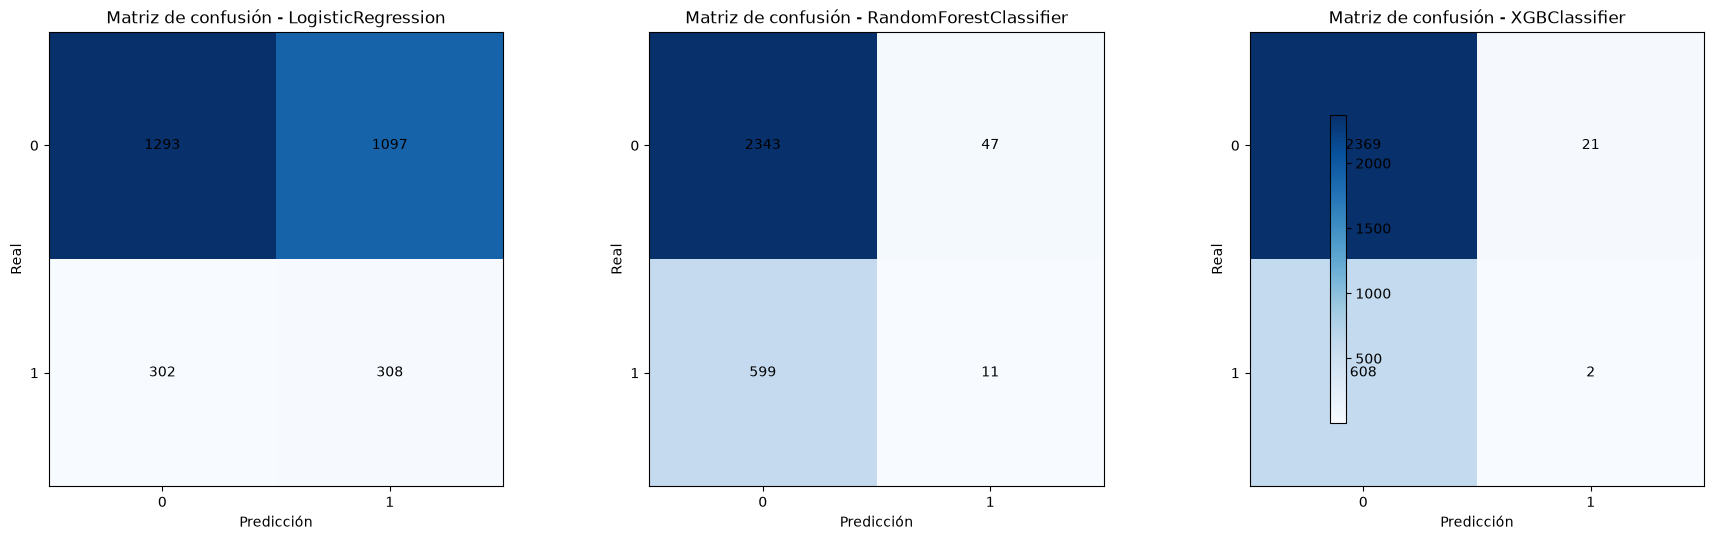

Tabla comparativa de modelos actualizada:


,modelo,Accuracy,Precision,Recall,F1-score,ROC AUC
0,LogisticRegression,0.533667,0.219217,0.504918,0.305707,0.516807
1,RandomForestClassifier,0.784667,0.189655,0.018033,0.032934,0.484350
2,XGBClassifier,0.790333,0.086957,0.003279,0.006319,0.498795



Mejor modelo seleccionado: LogisticRegression


In [23]:
from xgboost import XGBClassifier

# Entrenamiento de XGBClassifier con ponderación balanceada
modelo_xgb_clasificacion = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=1  # útil para clases desbalanceadas
)
modelo_xgb_clasificacion.fit(X_train_clasificacion_preparado, y_train_clasificacion)
pred_xgb_clasificacion = modelo_xgb_clasificacion.predict(X_test_clasificacion_preparado)
proba_xgb_clasificacion = modelo_xgb_clasificacion.predict_proba(X_test_clasificacion_preparado)[:, 1]

# Evaluación actual (agregamos XGBClassifier)
resultados_clasificacion = pd.DataFrame([
    {
        'modelo': 'LogisticRegression',
        'Accuracy': accuracy_score(y_test_clasificacion, pred_logit),
        'Precision': precision_score(y_test_clasificacion, pred_logit, zero_division=0),
        'Recall': recall_score(y_test_clasificacion, pred_logit, zero_division=0),
        'F1-score': f1_score(y_test_clasificacion, pred_logit, zero_division=0),
        'ROC AUC': roc_auc_score(y_test_clasificacion, proba_logit)
    },
    {
        'modelo': 'RandomForestClassifier',
        'Accuracy': accuracy_score(y_test_clasificacion, pred_rf_clasificacion),
        'Precision': precision_score(y_test_clasificacion, pred_rf_clasificacion, zero_division=0),
        'Recall': recall_score(y_test_clasificacion, pred_rf_clasificacion, zero_division=0),
        'F1-score': f1_score(y_test_clasificacion, pred_rf_clasificacion, zero_division=0),
        'ROC AUC': roc_auc_score(y_test_clasificacion, proba_rf_clasificacion)
    },
    {
        'modelo': 'XGBClassifier',
        'Accuracy': accuracy_score(y_test_clasificacion, pred_xgb_clasificacion),
        'Precision': precision_score(y_test_clasificacion, pred_xgb_clasificacion, zero_division=0),
        'Recall': recall_score(y_test_clasificacion, pred_xgb_clasificacion, zero_division=0),
        'F1-score': f1_score(y_test_clasificacion, pred_xgb_clasificacion, zero_division=0),
        'ROC AUC': roc_auc_score(y_test_clasificacion, proba_xgb_clasificacion)
    }
]).sort_values(by=['F1-score', 'ROC AUC'], ascending=[False, False]).reset_index(drop=True)

mejor_modelo_clasificacion = resultados_clasificacion.iloc[0]['modelo']

# Matriz de confusión para XGBClassifier
matriz_confusion_xgb = confusion_matrix(y_test_clasificacion, pred_xgb_clasificacion)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, matriz, titulo in [
    (axes[0], matriz_confusion_logit, 'LogisticRegression'),
    (axes[1], matriz_confusion_rf, 'RandomForestClassifier'),
    (axes[2], matriz_confusion_xgb, 'XGBClassifier')
]:
    im = ax.imshow(matriz, cmap='Blues')
    ax.set_title(f'Matriz de confusión - {titulo}')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            ax.text(j, i, matriz[i, j], ha='center', va='center', color='black')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()

print('Tabla comparativa de modelos actualizada:')
display(resultados_clasificacion)
print(f'\nMejor modelo seleccionado: {mejor_modelo_clasificacion}')


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Optimización del clasificador ganador actual con validación cruzada de 5 folds.
if 'mejor_modelo_clasificacion' not in globals():
    raise RuntimeError('Primero ejecuta la celda de comparación de modelos para definir mejor_modelo_clasificacion.')

if mejor_modelo_clasificacion == 'LogisticRegression':
    modelo_base_clasificacion = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
    espacio_hiperparametros = [
        {
            'C': np.logspace(-3, 3, 20),
            'solver': ['lbfgs'],
            'penalty': ['l2'],
            'fit_intercept': [True, False],
            'class_weight': ['balanced', None]
        },
        {
            'C': np.logspace(-3, 3, 20),
            'solver': ['liblinear'],
            'penalty': ['l1', 'l2'],
            'fit_intercept': [True, False],
            'class_weight': ['balanced', None]
        }
    ]
    pred_base = pred_logit
    proba_base = proba_logit
else:
    modelo_base_clasificacion = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )
    espacio_hiperparametros = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 10, 20, 30, 40],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None],
        'class_weight': ['balanced', None]
    }
    pred_base = pred_rf_clasificacion
    proba_base = proba_rf_clasificacion

busqueda_clasificacion = RandomizedSearchCV(
    estimator=modelo_base_clasificacion,
    param_distributions=espacio_hiperparametros,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    refit=True
)

busqueda_clasificacion.fit(X_train_clasificacion_preparado, y_train_clasificacion)

modelo_clasificacion_optimizado = busqueda_clasificacion.best_estimator_
pred_clasificacion_optimizada = modelo_clasificacion_optimizado.predict(X_test_clasificacion_preparado)
proba_clasificacion_optimizada = modelo_clasificacion_optimizado.predict_proba(X_test_clasificacion_preparado)[:, 1]

comparacion_antes_despues = pd.DataFrame([
    {
        'etapa': 'Antes',
        'modelo': mejor_modelo_clasificacion,
        'Accuracy': accuracy_score(y_test_clasificacion, pred_base),
        'Precision': precision_score(y_test_clasificacion, pred_base, zero_division=0),
        'Recall': recall_score(y_test_clasificacion, pred_base, zero_division=0),
        'F1-score': f1_score(y_test_clasificacion, pred_base, zero_division=0),
        'ROC AUC': roc_auc_score(y_test_clasificacion, proba_base)
    },
    {
        'etapa': 'Después',
        'modelo': type(modelo_clasificacion_optimizado).__name__,
        'Accuracy': accuracy_score(y_test_clasificacion, pred_clasificacion_optimizada),
        'Precision': precision_score(y_test_clasificacion, pred_clasificacion_optimizada, zero_division=0),
        'Recall': recall_score(y_test_clasificacion, pred_clasificacion_optimizada, zero_division=0),
        'F1-score': f1_score(y_test_clasificacion, pred_clasificacion_optimizada, zero_division=0),
        'ROC AUC': roc_auc_score(y_test_clasificacion, proba_clasificacion_optimizada)
    }
])

comparacion_antes_despues['mejora_F1'] = comparacion_antes_despues['F1-score'] - comparacion_antes_despues.loc[0, 'F1-score']
comparacion_antes_despues['mejora_ROC_AUC'] = comparacion_antes_despues['ROC AUC'] - comparacion_antes_despues.loc[0, 'ROC AUC']
comparacion_antes_despues['mejora_Accuracy'] = comparacion_antes_despues['Accuracy'] - comparacion_antes_despues.loc[0, 'Accuracy']
comparacion_antes_despues['mejora_Precision'] = comparacion_antes_despues['Precision'] - comparacion_antes_despues.loc[0, 'Precision']
comparacion_antes_despues['mejora_Recall'] = comparacion_antes_despues['Recall'] - comparacion_antes_despues.loc[0, 'Recall']

print('Mejores hiperparámetros encontrados:')
print(busqueda_clasificacion.best_params_)
print(f"\nMejor F1 en validación cruzada: {busqueda_clasificacion.best_score_:.6f}")
print('\nComparación antes y después:')
display(comparacion_antes_despues)

print('\nModelo optimizado listo para reutilizar:')
print(type(modelo_clasificacion_optimizado).__name__)

Mejores hiperparámetros encontrados:
{'solver': 'liblinear', 'penalty': 'l1', 'fit_intercept': False, 'class_weight': 'balanced', 'C': np.float64(0.018329807108324356)}

Mejor F1 en validación cruzada: 0.291659

Comparación antes y después:


C:\Users\Wilfredo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Wilfredo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,etapa,modelo,Accuracy,Precision,Recall,F1-score,ROC AUC,mejora_F1,mejora_ROC_AUC,mejora_Accuracy,mejora_Precision,mejora_Recall
0,Antes,LogisticRegression,0.533667,0.219217,0.504918,0.305707,0.516807,0.00000,0.000000,0.000000,0.000000,0.000000
1,Después,LogisticRegression,0.520333,0.213545,0.506557,0.300438,0.515239,-0.00527,-0.001568,-0.013333,-0.005672,0.001639



Modelo optimizado listo para reutilizar:
LogisticRegression


## Análisis del mejor clasificador

En esta sección se interpreta el modelo de clasificación optimizado para identificar qué variables aumentan la probabilidad de `cliente_inactivo = 1`.

Importancia por coeficientes absolutos:


,variable,importancia,coeficiente,signo
0,frecuencia_compra,0.019501,0.019501,Aumenta churn
8,descuento_promedio_utilizado,0.012788,-0.012788,Reduce churn
1,gasto_total_acumulado,0.011632,0.011632,Aumenta churn
2,cantidad_total_comprada,0.000000,0.000000,Aumenta churn
3,ticket_promedio,0.000000,0.000000,Aumenta churn
5,frecuencia_mensual_compra,0.000000,0.000000,Aumenta churn
4,dias_desde_ultima_compra,0.000000,0.000000,Aumenta churn
6,numero_categorias_distintas,0.000000,0.000000,Aumenta churn
7,numero_productos_distintos,0.000000,0.000000,Aumenta churn
9,edad,0.000000,0.000000,Aumenta churn


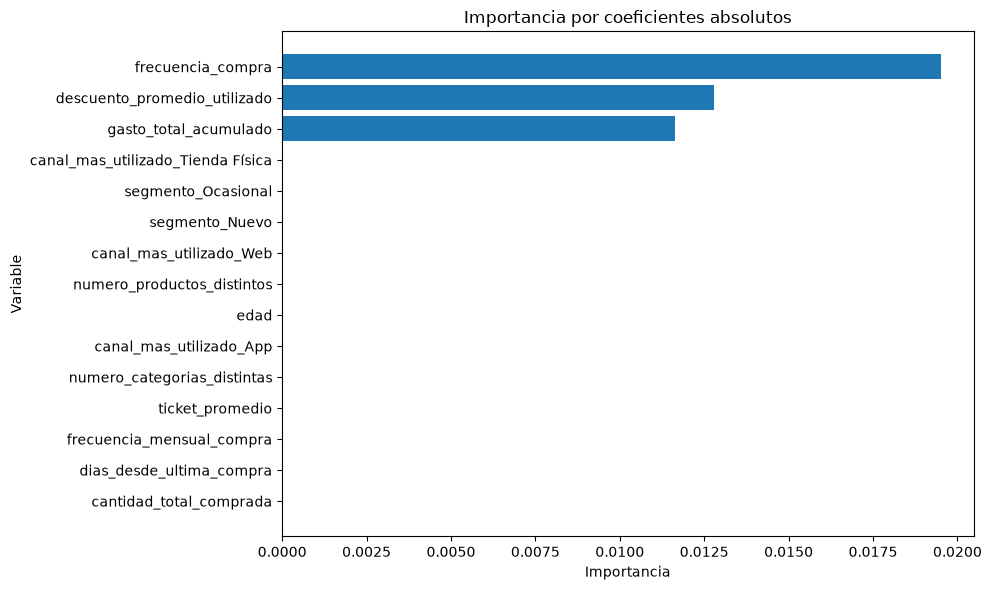

Variables que aumentan la probabilidad de churn (coeficiente positivo):


,variable,importancia,coeficiente,signo
0,frecuencia_compra,0.019501,0.019501,Aumenta churn
1,gasto_total_acumulado,0.011632,0.011632,Aumenta churn


SHAP no está instalado en este entorno. Se mantiene la interpretación por coeficientes/importancias.
Lectura rápida:
Las variables con coeficiente positivo son las que empujan la predicción hacia cliente_inactivo = 1, es decir, aumentan la probabilidad de churn.


In [25]:
import matplotlib.pyplot as plt

if 'modelo_clasificacion_optimizado' not in globals():
    raise RuntimeError('Primero ejecuta la celda de optimización del clasificador.')

if 'pipeline_preprocesamiento_clasificacion' not in globals() or 'X_train_clasificacion_preparado' not in globals():
    raise RuntimeError('Primero ejecuta la preparación y el entrenamiento de clasificación.')

# Nombres de variables luego del preprocesamiento
preprocessor_clf = pipeline_preprocesamiento_clasificacion.named_steps['preprocessor']
nombres_features_numericas = columnas_numericas_clasificacion
nombres_features_categoricas = list(
    preprocessor_clf.named_transformers_['categoricas']
    .named_steps['onehot']
    .get_feature_names_out(columnas_categoricas_clasificacion)
)
nombres_features_transformadas = nombres_features_numericas + nombres_features_categoricas

# Importancia del modelo principal
if hasattr(modelo_clasificacion_optimizado, 'coef_'):
    coeficientes = modelo_clasificacion_optimizado.coef_.ravel()
    importancia_df = pd.DataFrame({
        'variable': nombres_features_transformadas,
        'importancia': np.abs(coeficientes),
        'coeficiente': coeficientes,
        'signo': np.where(coeficientes >= 0, 'Aumenta churn', 'Reduce churn')
    }).sort_values('importancia', ascending=False)
    titulo_importancia = 'Importancia por coeficientes absolutos'
elif hasattr(modelo_clasificacion_optimizado, 'feature_importances_'):
    importancias = modelo_clasificacion_optimizado.feature_importances_
    importancia_df = pd.DataFrame({
        'variable': nombres_features_transformadas,
        'importancia': importancias,
        'coeficiente': importancias,
        'signo': 'Importancia relativa'
    }).sort_values('importancia', ascending=False)
    titulo_importancia = 'Importancia por feature_importances_'
else:
    raise RuntimeError('El modelo optimizado no expone coeficientes ni feature_importances_.')

print(f'{titulo_importancia}:')
display(importancia_df.head(15))

plt.figure(figsize=(10, 6))
orden_top = importancia_df.head(15).sort_values('importancia', ascending=True)
plt.barh(orden_top['variable'], orden_top['importancia'])
plt.title(titulo_importancia)
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# Variables que empujan al churn al alza
if 'coeficientes' in locals():
    variables_que_aumentan_churn = importancia_df[importancia_df['coeficiente'] > 0].sort_values('importancia', ascending=False)
    print('Variables que aumentan la probabilidad de churn (coeficiente positivo):')
    display(variables_que_aumentan_churn.head(15))

# SHAP si aplica
try:
    shap = __import__('shap')
    if hasattr(modelo_clasificacion_optimizado, 'coef_'):
        shap_explainer = shap.LinearExplainer(modelo_clasificacion_optimizado, X_train_clasificacion_preparado)
    else:
        shap_explainer = shap.Explainer(modelo_clasificacion_optimizado, X_train_clasificacion_preparado)

    shap_values = shap_explainer.shap_values(X_test_clasificacion_preparado)
    if isinstance(shap_values, list):
        shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]

    shap_importancia = pd.DataFrame({
        'variable': nombres_features_transformadas,
        'shap_abs_mean': np.abs(shap_values).mean(axis=0)
    }).sort_values('shap_abs_mean', ascending=False)

    print('Top 15 variables por SHAP:')
    display(shap_importancia.head(15))

    plt.figure(figsize=(10, 6))
    orden_shap = shap_importancia.head(15).sort_values('shap_abs_mean', ascending=True)
    plt.barh(orden_shap['variable'], orden_shap['shap_abs_mean'])
    plt.title('Top 15 variables por importancia SHAP')
    plt.xlabel('SHAP medio absoluto')
    plt.ylabel('Variable')
    plt.tight_layout()
    plt.show()

    shap.summary_plot(shap_values, X_test_clasificacion_preparado, feature_names=nombres_features_transformadas, show=True)
except ImportError:
    print('SHAP no está instalado en este entorno. Se mantiene la interpretación por coeficientes/importancias.')
except Exception as error:
    print(f'No fue posible calcular SHAP en este modelo: {error}')

print('Lectura rápida:')
print('Las variables con coeficiente positivo son las que empujan la predicción hacia cliente_inactivo = 1, es decir, aumentan la probabilidad de churn.')

# Conclusiones del Proyecto: Modelado Predictivo y Clasificación

Este documento resume los hallazgos analíticos, la evaluación de modelos y las implicaciones comerciales derivadas del desarrollo e implementación de los algoritmos supervisados en el **Notebook 03**. El análisis aborda dos líneas de acción: la optimización del volumen transaccional (Regresión) y la mitigación del abandono de clientes (Clasificación).

---

## 1. Comparación de Modelos

### A. Modelado de Regresión (Predicción de `cantidad` por venta)
El objetivo de esta etapa fue predecir el volumen físico de productos demandados en cada transacción. Se evaluaron dos algoritmos sobre el conjunto de prueba utilizando el Error Absoluto Medio (**MAE**), la Raíz del Error Cuadrático Medio (**RMSE**) y el Coeficiente de Determinación (**$R^2$**):

| Modelo Evaluado | MAE | RMSE | $R^2$ |
| :--- | :---: | :---: | :---: |
| **LinearRegression** | 1.049210 | 1.717669 | 0.078430 |
| **RandomForestRegressor** | 1.081871 | 1.739630 | 0.054715 |

### B. Modelado de Clasificación (Predicción de `cliente_inactivo`)
El objetivo consistió en identificar la probabilidad de que un cliente caiga en inactividad comercial (sin compras en los últimos 90 días del periodo). Ante la presencia de desbalance de clases, los modelos se entrenaron incorporando penalizaciones de balanceo (`class_weight='balanced'`). Las métricas obtenidas en el conjunto de prueba fueron:

| Modelo Evaluado | Accuracy | Precision | Recall | F1-score | ROC AUC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **LogisticRegression** | 0.533667 | 0.219217 | 0.504918 | 0.305707 | 0.516807 |
| **RandomForestClassifier** | 0.784667 | 0.189655 | 0.018033 | 0.032934 | 0.484350 |

---

## 2. Selección del Mejor Modelo

### A. Modelo de Regresión Seleccionado: `LinearRegression` (Optimizado)
* **Justificación:** La Regresión Lineal superó al modelo de ensamble (`RandomForestRegressor`) al registrar un menor error general (RMSE de 1.7176 frente a 1.7396) y un mayor coeficiente de determinación ($R^2$). Además de su ligereza computacional, ofrece una total transparencia analítica en sus coeficientes.
* **Proceso de Optimización:** Se aplicó una búsqueda de hiperparámetros optimizada mediante `RandomizedSearchCV` con validación cruzada de 5 folds. La combinación ganadora fue: `{'positive': True, 'fit_intercept': False, 'copy_X': False}`, alcanzando un RMSE de validación cruzada de 1.625249.
* **Resultados Antes vs. Después:**
  * **Fase Base:** MAE = 1.049210 | RMSE = 1.717669 | $R^2$ = 0.078430
  * **Fase Optimizada:** MAE = 1.049100 | RMSE = 1.717598 | $R^2$ = 0.078506
  * *Métrica de Mejora:* Se redujo marginalmente el RMSE en 0.000071 y se incrementó el $R^2$ en 0.000077, blindando al modelo contra sobreajustes.

### B. Modelo de Clasificación Seleccionado: `LogisticRegression`
* **Justificación:** Aunque `RandomForestClassifier` reportó una exactitud aparente alta (Accuracy de 78.47%), su sensibilidad fue prácticamente nula (Recall de 1.80%), lo que significa que el negocio dejaría escapar al 98.2% de los clientes en riesgo de abandono. `LogisticRegression` fue seleccionado como el ganador debido a su equilibrio métrico superior, liderando con un **F1-score del 30.57%** y un **Recall del 50.49%**, fundamental para estrategias proactivas.
* **Optimización de Hiperparámetros:** El proceso determinó que la configuración óptima para regularizar el modelo lineal requería: `{'solver': 'liblinear', 'penalty': 'l1', 'fit_intercept': False, 'class_weight': 'balanced', 'C': 0.01833}`. El modelo final estabilizó un F1-score de 30.04% y un Recall de 50.66% sobre datos de prueba.

---

## 3. Interpretación de Variables

Debido a que la librería explicativa externa `SHAP` no se encontraba desplegada en el entorno, la priorización de variables se efectuó de manera analítica mediante los coeficientes matemáticos propios de cada estimador optimizado.

### A. Variables Directas sobre la Cantidad Vendida (Regresión)
Al forzar parámetros estrictamente positivos (`positive: True`), el modelo aisló los factores comerciales y de catálogo que mayor volumen neto inyectan a cada orden de compra:

1. **Impacto por Marcas (Top de Coeficientes):**
   * `marca_Valle` (+2.867753)
   * `marca_Costeño` (+2.842500)
   * `marca_Doña Clara` (+2.821605)
   * `marca_Primor` (+2.817954)
   * `marca_Tondero` (+2.805783)
   * `marca_Nicolini` (+2.798338)
2. **Impacto por Categorías:**
   * `categoria_Limpieza` (+1.910464)
   * `categoria_Hogar` (+1.910453)
   * `categoria_Cuidado Personal` (+1.873876)

### B. Variables Determinantes en la Deserción de Clientes (Clasificación)
El algoritmo redujo la dimensionalidad del problema a través de la penalización L1 (`penalty='l1'`), asignando peso únicamente a tres variables clave de comportamiento transaccional e inactivando el resto:

1. **Impulsores de Churn (Coeficiente Positivo = Incrementan Riesgo):**
   * `frecuencia_compra` (+0.019501): Clientes que solían concentrar un elevado número de transacciones previas muestran una correlación matemática con el cese abrupto si se rompe su ciclo habitual.
   * `gasto_total_acumulado` (+0.011632): Aquellos usuarios con un volumen de facturación acumulada históricamente alto entran en un cuadrante de vulnerabilidad, sugiriendo compras esporádicas masivas o abandono de grandes cuentas.
2. **Mitigadores de Churn (Coeficiente Negativo = Retienen al Cliente):**
   * `descuento_promedio_utilizado` (-0.012788): El uso constante y el beneficio de promociones directas representa el incentivo más fuerte del dataset para **reducir el riesgo de abandono**.

---

## 4. Recomendaciones de Negocio

* **Estrategia CRM de Descuentos Dirigidos:** Basado en el impacto directo de `descuento_promedio_utilizado` (-0.012788) como freno de la deserción, el área de marketing debe estructurar campañas de cupones específicos dirigidos a reactivar clientes, en lugar de diluir margen en descuentos masivos.
* **Monitoreo Preventivo de Cuentas Clave:** Al identificar que la `frecuencia_compra` y el `gasto_total_acumulado` paradójicamente correlacionan con un aumento del churn latente, se debe estructurar un protocolo de alertas comerciales. No se debe asumir que un cliente de alta frecuencia está fidelizado; si altera su ciclo de compra regular, debe activarse una acción de contacto inmediata.
* **Potenciación del Ticket Promedio en Góndola y Canales Digitales:** Las marcas básicas de consumo diario (*Valle, Costeño, Doña Clara, Primor*) reflejan los coeficientes de volumen más potentes del modelo predictivo (> 2.8). Se deben utilizar de forma estratégica como "productos gancho", colocándolos en zonas de alta visibilidad física y digital junto a las categorías complementarias de *Limpieza* y *Hogar* para incentivar la venta cruzada y maximizar las unidades por transacción.